In [1]:
import pickle
with open("distance_clust_sols.pkl", "rb") as f:
    distance_clust_sols = pickle.load(f)



In [2]:
len(distance_clust_sols)


36

In [3]:
import base64
import io
import pickle
import functools
import itertools

import jax.numpy as jnp
import jax
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_debug_key_reuse", True)

# set cache size to 1GB
jax.config.update("jax_compilation_cache_max_size", 2**30 - 1)

# jax.config.update("jax_log_compiles", True)
# jax.config.update("jax_compiler_detailed_logging_min_ops", 50)

# jax.config.update("jax_explain_cache_misses", True)
# jax.config.update("jax_check_tracer_leaks", True)
# jax.config.update("jax_debug_nans", True)

import orthax

import matplotlib
import matplotlib.pyplot as plt
# import matplotlib.animation as animation
import pandas as pd
from scipy.io import loadmat, savemat
from scipy.stats import ranksums

# import plotly.graph_objects as go

from hnmf_tr_optimizer.hnmf_optimizer import HNMFOptimizer, NewHNMFOptimizer, PerturbanceHNMFOptimizer, RedoHNMFOptimizer
from hnmf_tr_optimizer.clusts import result_analysis

from dls_model import InitParamsGenerator2, clustering_preprocess
# plt.style.use('Solarize_Light2')

# from IPython.display import Markdown, display



ERROR:2025-08-29 12:46:24,336:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 304; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [4]:
# # Plotting theme setup


# TEXT_COLOR = "white"
# BG_COLOR = "black"

# plt.rcParams["axes.facecolor"] = plt.rcParams["figure.facecolor"] = BG_COLOR
# plt.rcParams["text.color"] = TEXT_COLOR
# plt.rcParams["axes.labelcolor"] = TEXT_COLOR
# plt.rcParams["xtick.color"] = TEXT_COLOR
# plt.rcParams["ytick.color"] = TEXT_COLOR
# plt.rcParams.update({
# 	"axes.grid" : True,
# 	"grid.color": "green",
# 	"grid.alpha": 0.35,
# 	"grid.linestyle": (0, (10, 10)),
# })

# # BETTER SIZES
# DEFAULT_W, DEFAULT_H = (16, 9)
# plt.rcParams["figure.figsize"] = [DEFAULT_W, DEFAULT_H]
# plt.rcParams["font.size"] = 14
# plt.rcParams["figure.dpi"] = 90

# plt.style.use('dark_background')


In [5]:
def generate_distributions_by_distance(amp_pairs, lower_means, mean_distances, std_devs):
    core_params = list(itertools.product(std_devs, lower_means, mean_distances))
    all_combinations = []
    for amp1, amp2 in amp_pairs:
        for std, mean1, dist in core_params:
            mean2 = mean1 + dist
            all_combinations.append([amp1, mean1, std, amp2, mean2, std])

    return jnp.array(all_combinations)


SCALING_CONST = 2.45e-7

amplitude_pairs = [[0.5, 0.5]]
means = jnp.arange(1.8e-6, 1.9e-5, 6e-6).tolist()
mean_diffs = jnp.arange(5e-7, 5.1e-6, 1.5e-6).tolist()
stds = jnp.arange(6.5e-7, 1.31e-6, 3e-7).tolist()

distanced_params = generate_distributions_by_distance(amplitude_pairs, means, mean_diffs, stds)
amp1, mean1, std1, amp2, mean2, std2 = distanced_params.T
valid_params = distanced_params = jnp.stack([amp1, amp2, mean1, mean2, std1, std2]).T.reshape(distanced_params.shape[0], 3, 2)


In [6]:
def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s
    g2_minus1_obs = d[:, 1:].T
    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g2_minus1_obs

q, t, _ = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")


In [7]:
num_resids = len(q)*len(t)


def AIC3(sill_avg, recon, num_sources, sill_cutoff=0.7):
    if sill_avg > sill_cutoff:
        aic = 2*num_sources + 2*jnp.log(recon)
    else:
        aic = jnp.inf
    return aic

def BIC(sill_avg, recon, num_resids, num_sources, sill_cutoff=0.7):
    if sill_avg > sill_cutoff:
        aic = num_sources*jnp.log(num_resids) + 2*jnp.log(recon)
    else:
        aic = jnp.inf
    return aic

# for df in final_clust_sols:
#     df['aic_score'] = df.apply(lambda row: AIC3(row['min_sillhouette_score'], row['reconstruction_loss'], row.name), axis=1)

for df in distance_clust_sols:
    df['aic_score'] = df.apply(lambda row: BIC(row['min_sillhouette_score'], row['reconstruction_loss'], num_resids, row.name), axis=1)

# final_clust_sols[0].apply(lambda row: BIC(row['min_sillhouette_score'], row['reconstruction_loss'], num_resids, row.name), axis=1)
# final_clust_sols[0].apply(lambda row: row.name, axis=1)


In [42]:
separated = [df['aic_score'].argmin() == 1 for df in distance_clust_sols]
separtion_df = pd.DataFrame({"successully separated": separated, "lower mean": SCALING_CONST*mean1, "distance between means": SCALING_CONST*(mean2 - mean1), "st dev": SCALING_CONST*std2})
separtion_df


,successully separated,lower mean,distance between means,st dev
0,True,4.410000e-13,1.225000e-13,1.592500e-13
1,True,4.410000e-13,4.900000e-13,1.592500e-13
2,True,4.410000e-13,8.575000e-13,1.592500e-13
3,True,4.410000e-13,1.225000e-12,1.592500e-13
4,False,1.911000e-12,1.225000e-13,1.592500e-13
5,True,1.911000e-12,4.900000e-13,1.592500e-13
6,True,1.911000e-12,8.575000e-13,1.592500e-13
7,True,1.911000e-12,1.225000e-12,1.592500e-13
8,False,3.381000e-12,1.225000e-13,1.592500e-13
9,False,3.381000e-12,4.900000e-13,1.592500e-13


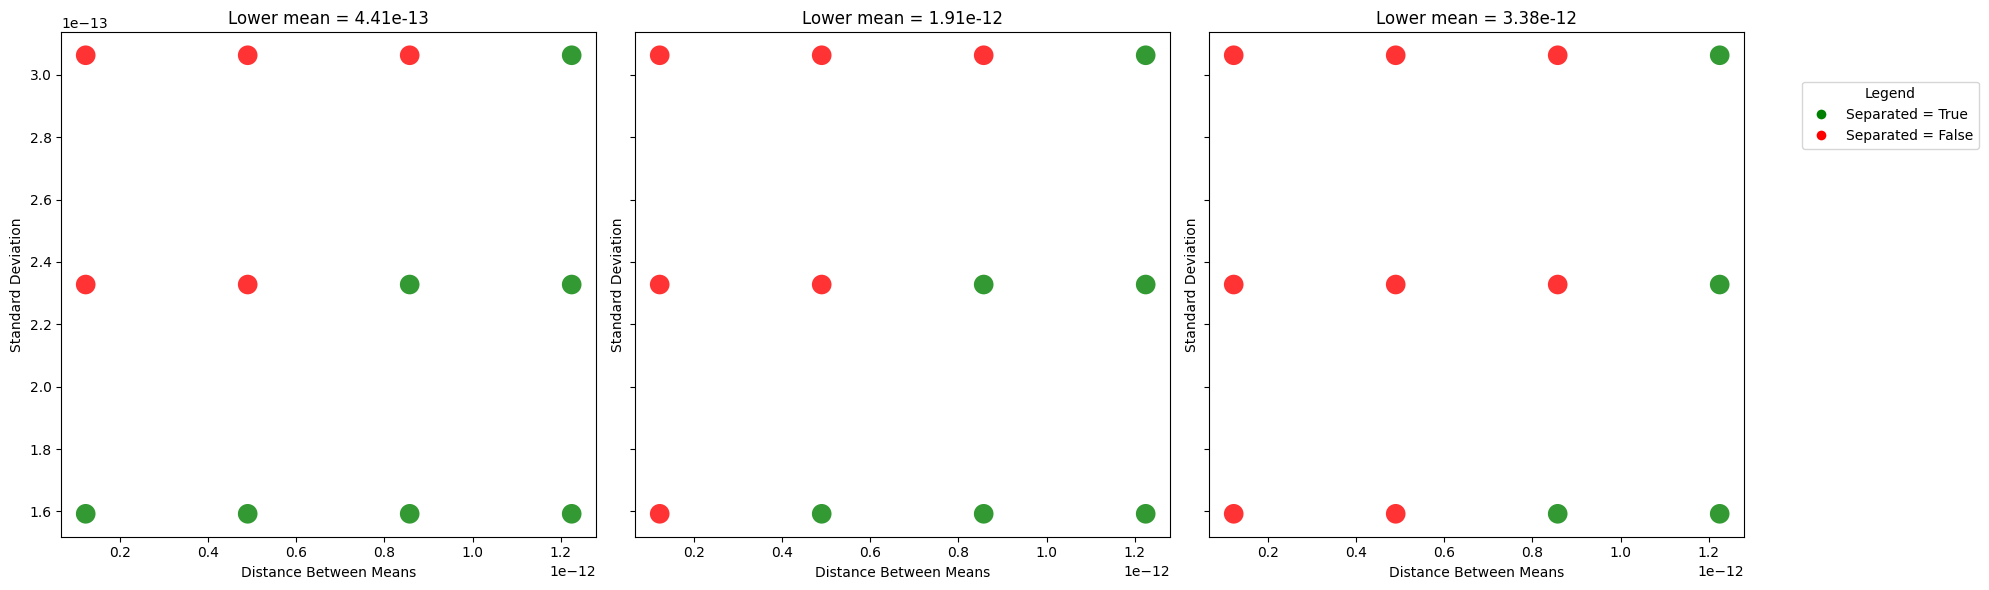

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Extract unique lower mean values
lower_means = separtion_df["lower mean"].unique()
n_plots = len(lower_means)

# Create subplots with one axis per unique lower mean
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6), sharey=True)

# If only one subplot, wrap into a list for easy iteration
if n_plots == 1:
    axes = [axes]

for ax, lm in zip(axes, lower_means):
    subset = separtion_df[separtion_df["lower mean"] == lm]
    colors = subset["successully separated"].map({True: "green", False: "red"})

    ax.scatter(
        subset["distance between means"],
        subset["st dev"],
        s=200.0,
        c=colors,
        alpha=0.8,
        edgecolors="none",
    )

    ax.set_title(f"Lower mean = {lm:.2e}")
    ax.set_xlabel("Distance Between Means")
    ax.set_ylabel("Standard Deviation")

# Add one legend outside the whole figure
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Separated = True',
               markerfacecolor='green', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Separated = False',
               markerfacecolor='red', markersize=8)
]

fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1, 0.8), title="Legend")

plt.tight_layout(rect=[0, 0, 0.98, 1])  # Leave space for legend
plt.show()
